# Mundiales 2018, 2022 y 2026
## Preparación de datos y entrada al análisis supervisado

Trabajaremos exclusivamente con la fase de grupos. Los archivos contienen errores deliberados. No uses la base del profesor.

## Objetivos

- Perfilar datos.
- Estandarizar esquemas.
- Limpiar fechas, equipos, goles y marcadores.
- Eliminar duplicados con criterio.
- Comparar torneos mediante tasas.
- Construir variables conocidas antes de cada partido.
- Entrenar un primer clasificador y detectar fuga de información.

In [1]:
from pathlib import Path
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

DATA = Path('../datos')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)


## Cargar los tres archivos

In [2]:
d18 = pd.read_csv(DATA / 'mundial_2018_sucio.csv', dtype=str)
d22 = pd.read_csv(DATA / 'mundial_2022_sucio.csv', dtype=str)
d26 = pd.read_csv(DATA / 'mundial_2026_sucio.csv', dtype=str)

for df, nombre in [(d18,'2018'),(d22,'2022'),(d26,'2026')]:
    print(f'=== {nombre}: {df.shape} ===')
    print(df.head(3))
    print()


=== 2018: (50, 16) ===
  ID Partido   Año            Fase    Grupo Jornada       Fecha   Hora Equipo Local Equipo Visitante Goles Local  \
0  M-2018-01  2018  Fase de grupos  Grupo A       1  2018-06-14  18:00      russia               KSA     5 goles   
1  M-2018-02  2018     GROUP STAGE       A        1  15/06/2018  17:00        Egypt          Uruguay           0   
2  M-2018-03  2018          grupos  group-b       1  06/15/2018  18:00      Morocco       Iran, I.R.           0   

  Goles Visitante Marcador Anfitrión Local             Estadio            Ciudad  \
0             NaN      5-0              Sí    Luzhniki Stadium            Moscow   
1               1      0–1               0     Central Stadium     Yekaterinburg   
2               1    0 : 1           FALSE  Krestovsky Stadium  Saint Petersburg   

                                  Fuente  
0  https://github.com/jfjelstul/worldcup  
1  https://github.com/jfjelstul/worldcup  
2  https://github.com/jfjelstul/worldcup  

==

## Perfilado

Para cada archivo revisa:

- columnas;
- tipos;
- valores nulos;
- duplicados;
- valores únicos de grupos, fases y equipos;
- goles que no puedan convertirse directamente a número.

In [3]:
def perfil(df, nombre):
    print(f'\n{"="*60}')
    print(f'PERFIL: {nombre}  —  {df.shape[0]} filas × {df.shape[1]} columnas')
    print(f'Columnas: {list(df.columns)}')
    print()
    nulos = df.isnull().sum()
    print('Nulos por columna:')
    print(nulos[nulos > 0].to_string() if nulos.any() else '  (ninguno)')
    print(f'\nDuplicados (fila completa): {df.duplicated().sum()}')

    # Detectar goles que no son número puro
    col_local = [c for c in df.columns if 'gol' in c.lower() and 'local' in c.lower()] +                 [c for c in df.columns if c.upper() in ('HG', 'HOME_SCORE')]
    for c in col_local[:1]:
        no_num = df[c].dropna()
        no_num = no_num[~no_num.str.match(r'^-?\d+(\.\d+)?$', na=False)]
        if len(no_num):
            print(f'\nValores no numéricos en {c}:')
            print(no_num.value_counts().to_string())

perfil(d18, '2018')
perfil(d22, '2022')
perfil(d26, '2026')



PERFIL: 2018  —  50 filas × 16 columnas
Columnas: ['ID Partido', 'Año', 'Fase', 'Grupo', 'Jornada', 'Fecha', 'Hora', 'Equipo Local', 'Equipo Visitante', 'Goles Local', 'Goles Visitante', 'Marcador', 'Anfitrión Local', 'Estadio', 'Ciudad', 'Fuente']

Nulos por columna:
Grupo              1
Goles Visitante    3
Marcador           1

Duplicados (fila completa): 2

Valores no numéricos en Goles Local:
Goles Local
5 goles    2
1 goles    2

PERFIL: 2022  —  51 filas × 16 columnas
Columnas: ['match_id', 'WorldCup', 'stage', 'group_name', 'match_day', 'date', 'local', 'visitor', 'home_score', 'away_score', 'score_text', 'home_host', 'venue', 'city_name', 'comentario', 'source_url']

Nulos por columna:
group_name     1
date           1
home_score     4
comentario    13

Duplicados (fila completa): 3

PERFIL: 2026  —  75 filas × 14 columnas
Columnas: ['match', 'wc', 'round', 'grp', 'md', 'played_on', 'home', 'away', 'HG', 'AG', 'result_raw', 'host_h', 'host_a', 'source']

Nulos por columna:
gr

## Unificar nombres de columnas

In [4]:
rename_maps = {
    2018: {
        'ID Partido':      'partido_id',
        'Año':             'mundial',
        'Fase':            'fase',
        'Grupo':           'grupo',
        'Jornada':         'jornada',
        'Fecha':           'fecha',
        'Equipo Local':    'equipo_local',
        'Equipo Visitante':'equipo_visitante',
        'Goles Local':     'goles_local',
        'Goles Visitante': 'goles_visitante',
        'Marcador':        'marcador',
        'Anfitrión Local': 'local_es_anfitrion',
        'Estadio':         'estadio',
        'Ciudad':          'ciudad',
        'Fuente':          'fuente',
    },
    2022: {
        'match_id':    'partido_id',
        'WorldCup':    'mundial',
        'stage':       'fase',
        'group_name':  'grupo',
        'match_day':   'jornada',
        'date':        'fecha',
        'local':       'equipo_local',
        'visitor':     'equipo_visitante',
        'home_score':  'goles_local',
        'away_score':  'goles_visitante',
        'score_text':  'marcador',
        'home_host':   'local_es_anfitrion',
        'venue':       'estadio',
        'city_name':   'ciudad',
        'source_url':  'fuente',
    },
    2026: {
        'match':      'partido_id',
        'wc':         'mundial',
        'round':      'fase',
        'grp':        'grupo',
        'md':         'jornada',
        'played_on':  'fecha',
        'home':       'equipo_local',
        'away':       'equipo_visitante',
        'HG':         'goles_local',
        'AG':         'goles_visitante',
        'result_raw': 'marcador',
        'host_h':     'local_es_anfitrion',
        'host_a':     'visitante_es_anfitrion',
        'source':     'fuente',
    },
}

# Esquema canónico mínimo:
columnas_base = [
    'partido_id', 'mundial', 'fase', 'grupo', 'jornada', 'fecha',
    'equipo_local', 'equipo_visitante', 'goles_local',
    'goles_visitante', 'marcador', 'local_es_anfitrion',
    'visitante_es_anfitrion', 'fuente'
]

print('Mapas definidos para:', list(rename_maps.keys()))


Mapas definidos para: [2018, 2022, 2026]


## Normalizar equipos

No conviene borrar acentos del nombre que se mostrará. Crea una clave auxiliar sin acentos, minúscula y sin signos para buscar en el catálogo.

In [5]:
catalogo = pd.read_csv(DATA / 'catalogo_equipos.csv')

def clave_texto(valor):
    """Normaliza para comparación: sin acentos, minúscula, sin espacios/guiones."""
    if pd.isna(valor):
        return ''
    # Eliminar acentos con unicodedata
    nfkd = unicodedata.normalize('NFKD', str(valor))
    sin_acentos = ''.join(c for c in nfkd if not unicodedata.combining(c))
    return re.sub(r'[^a-z0-9]', '', sin_acentos.lower())

# Diccionario clave_normalizada -> nombre_canonico
dic_equipos = {
    clave_texto(row['variante']): row['nombre_canonico']
    for _, row in catalogo.iterrows()
}

def normalizar_equipo(nombre):
    clave = clave_texto(nombre)
    return dic_equipos.get(clave, str(nombre).strip())

# Verificación
for test in ['USA', 'Korea Republic', 'Cabo Verde', 'FRANCE', 'Curaçao']:
    print(f'  {test!r:25s} -> {normalizar_equipo(test)!r}')


  'USA'                     -> 'United States'
  'Korea Republic'          -> 'South Korea'
  'Cabo Verde'              -> 'Cape Verde'
  'FRANCE'                  -> 'France'
  'Curaçao'                 -> 'Curacao'


## Fechas, grupos, booleanos y marcadores

In [6]:
rangos = {
    2018: ('2018-06-14', '2018-06-28'),
    2022: ('2022-11-20', '2022-12-02'),
    2026: ('2026-06-11', '2026-06-27'),
}

# Origen de los seriales de Excel (Windows)
EXCEL_ORIGIN = pd.Timestamp('1899-12-30')

def convertir_fecha(valor, mundial):
    """Convierte cadenas de fecha en múltiples formatos a pd.Timestamp."""
    if pd.isna(valor) or str(valor).strip() == '':
        return pd.NaT
    s = str(valor).strip()
    # Serial de Excel: número entero o float
    try:
        n = float(s)
        if 30000 < n < 60000:  # Rango razonable para fechas del siglo XXI
            return EXCEL_ORIGIN + pd.Timedelta(days=int(n))
    except ValueError:
        pass
    # Varios formatos textuales
    for fmt in ('%Y-%m-%d','%d/%m/%Y','%m/%d/%Y','%d-%m-%y','%b %d, %Y','%B %d, %Y'):
        try:
            return pd.Timestamp(valor, unit=None) if False else pd.to_datetime(s, format=fmt)
        except Exception:
            pass
    try:
        from dateutil import parser as dp
        return pd.Timestamp(dp.parse(s, dayfirst=True))
    except Exception:
        return pd.NaT

def extraer_numero(valor):
    """Devuelve el primer entero encontrado en la cadena, o NaN."""
    if pd.isna(valor):
        return np.nan
    m = re.search(r'-?\d+', str(valor))
    return int(m.group()) if m else np.nan

def separar_marcador(valor):
    """Devuelve (gl, gv) desde marcadores con -, –, —, :, x. Devuelve (NaN, NaN) si no puede."""
    if pd.isna(valor) or str(valor).strip().lower() in ('sin dato', 's/d', ''):
        return np.nan, np.nan
    t = re.sub(r'\s*[\u2013\u2014:xX]\s*', '-', str(valor).strip())
    t = re.sub(r'\s*-\s*', '-', t)
    m = re.match(r'^(\d+)-(\d+)$', t)
    if m:
        return int(m.group(1)), int(m.group(2))
    return np.nan, np.nan

def normalizar_grupo(valor):
    """Extrae la letra del grupo (A-L)."""
    if pd.isna(valor) or str(valor).strip() == '':
        return np.nan
    m = re.search(r'[A-La-l]', str(valor))
    return m.group().upper() if m else np.nan

def normalizar_booleano(valor):
    """Convierte Sí/si/1/TRUE/True → True, resto → False."""
    if pd.isna(valor):
        return False
    return str(valor).strip().lower() in ('sí', 'si', '1', 'true')

print('Funciones de transformación definidas.')


Funciones de transformación definidas.


## Función de limpieza reproducible

In [7]:
def limpiar_mundial(df, mundial):
    d = df.rename(columns=rename_maps[mundial]).copy()

    # Columnas faltantes del esquema canónico
    for col in columnas_base:
        if col not in d.columns:
            d[col] = np.nan

    d['mundial'] = mundial

    # Equipos
    d['equipo_local']     = d['equipo_local'].apply(normalizar_equipo)
    d['equipo_visitante'] = d['equipo_visitante'].apply(normalizar_equipo)

    # Grupo
    d['grupo'] = d['grupo'].apply(normalizar_grupo)

    # Fecha
    d['fecha'] = d['fecha'].apply(lambda x: convertir_fecha(x, mundial))

    # Jornada (entero)
    d['jornada'] = pd.to_numeric(d['jornada'], errors='coerce').astype('Int64')

    # Booleanos
    d['local_es_anfitrion']    = d['local_es_anfitrion'].apply(normalizar_booleano)
    d['visitante_es_anfitrion']= d['visitante_es_anfitrion'].apply(normalizar_booleano)

    # Parsear marcador
    marc = d['marcador'].apply(separar_marcador)
    d['marc_local']   = [x[0] for x in marc]
    d['marc_visitante']= [x[1] for x in marc]

    # Reparar goles con marcador
    for idx, row in d.iterrows():
        gl = extraer_numero(row['goles_local'])
        gv = extraer_numero(row['goles_visitante'])
        ml, mv = row['marc_local'], row['marc_visitante']

        # Negativo → marcador
        if not np.isnan(gl) and gl < 0 and not np.isnan(ml):
            gl = ml
        # Vacío → marcador
        if np.isnan(gl) and not np.isnan(ml):
            gl = ml
        if np.isnan(gv) and not np.isnan(mv):
            gv = mv
        # Conflicto → marcador gana
        if not np.isnan(gl) and not np.isnan(ml) and gl != ml:
            gl = ml
        if not np.isnan(gv) and not np.isnan(mv) and gv != mv:
            gv = mv

        d.at[idx, 'goles_local']     = int(gl) if not np.isnan(gl) else np.nan
        d.at[idx, 'goles_visitante'] = int(gv) if not np.isnan(gv) else np.nan

    d['goles_local']     = pd.to_numeric(d['goles_local'],     errors='coerce').astype('Int64')
    d['goles_visitante'] = pd.to_numeric(d['goles_visitante'], errors='coerce').astype('Int64')

    # Infiere grupo faltante a partir de grupos del mismo equipo en el mismo torneo
    mask_sin_grupo = d['grupo'].isna()
    if mask_sin_grupo.any():
        mapa_grupo = {}
        for _, r in d[~mask_sin_grupo].iterrows():
            mapa_grupo[r['equipo_local']]     = r['grupo']
            mapa_grupo[r['equipo_visitante']] = r['grupo']
        for idx, r in d[mask_sin_grupo].iterrows():
            g = mapa_grupo.get(r['equipo_local']) or mapa_grupo.get(r['equipo_visitante'])
            if g:
                d.at[idx, 'grupo'] = g

    # Eliminar duplicados por partido_id
    d = d.drop_duplicates(subset='partido_id', keep='first').reset_index(drop=True)

    # Columnas derivadas
    d['marcador_limpio'] = d.apply(
        lambda r: f"{r.goles_local}-{r.goles_visitante}"
                  if pd.notna(r.goles_local) and pd.notna(r.goles_visitante) else '', axis=1)
    d['resultado_local'] = d.apply(
        lambda r: ('Local' if r.goles_local > r.goles_visitante
                   else ('Empate' if r.goles_local == r.goles_visitante else 'Visitante'))
        if pd.notna(r.goles_local) and pd.notna(r.goles_visitante) else '', axis=1)
    d['goles_totales']    = d['goles_local'] + d['goles_visitante']
    d['diferencia_goles'] = d['goles_local'] - d['goles_visitante']

    return d[columnas_base + ['marcador_limpio','resultado_local',
                               'goles_totales','diferencia_goles']]

limpio18 = limpiar_mundial(d18, 2018)
limpio22 = limpiar_mundial(d22, 2022)
limpio26 = limpiar_mundial(d26, 2026)
partidos = pd.concat([limpio18, limpio22, limpio26], ignore_index=True)

print(f'Partidos por mundial:\n{partidos.groupby("mundial")["partido_id"].count()}')
print(f'Total: {len(partidos)}')


Partidos por mundial:
mundial
2018    48
2022    48
2026    72
Name: partido_id, dtype: int64
Total: 168


## Validaciones obligatorias

La limpieza no termina cuando el código deja de producir errores. Debes comprobar invariantes.

In [8]:
print('\n=== VALIDACIONES ===')

# 1. Conteo por mundial
counts = partidos.groupby('mundial')['partido_id'].count()
esperados = {2018: 48, 2022: 48, 2026: 72}
for año, esperado in esperados.items():
    real = counts.get(año, 0)
    estado = '✓' if real == esperado else '✗'
    print(f'  {estado} Partidos {año}: {real} (esperado {esperado})')

# 2. Duplicados
n_dup = partidos['partido_id'].duplicated().sum()
print(f'  {"✓" if n_dup==0 else "✗"} Duplicados: {n_dup}')

# 3. Goles negativos
neg = ((partidos['goles_local'] < 0) | (partidos['goles_visitante'] < 0)).sum()
print(f'  {"✓" if neg==0 else "✗"} Goles negativos: {neg}')

# 4. Nulos críticos
for col in ['equipo_local','equipo_visitante','goles_local','goles_visitante']:
    n = partidos[col].isna().sum()
    print(f'  {"✓" if n==0 else "✗"} Nulos en {col}: {n}')

# 5. Marcador consistente
ok = (partidos['marcador_limpio'] ==
      partidos['goles_local'].astype(str) + '-' + partidos['goles_visitante'].astype(str))
print(f'  {"✓" if ok.all() else "✗"} Marcador consistente con goles: {ok.sum()}/{len(partidos)}')

# 6. Una fila por partido_id
una_fila = len(partidos) == partidos['partido_id'].nunique()
print(f'  {"✓" if una_fila else "✗"} Una fila por partido_id')



=== VALIDACIONES ===
  ✓ Partidos 2018: 48 (esperado 48)
  ✓ Partidos 2022: 48 (esperado 48)
  ✓ Partidos 2026: 72 (esperado 72)
  ✓ Duplicados: 0
  ✓ Goles negativos: 0
  ✓ Nulos en equipo_local: 0
  ✓ Nulos en equipo_visitante: 0
  ✓ Nulos en goles_local: 0
  ✓ Nulos en goles_visitante: 0
  ✓ Marcador consistente con goles: 168/168
  ✓ Una fila por partido_id


## Comparación de los Mundiales

   mundial  partidos  goles  goles_por_partido  empates  pct_empates  pct_victoria_anf  pct_alta_puntuacion
0     2018        48    122              2.542        9        0.188             1.000                0.500
1     2022        48    120                2.5       10        0.208             0.000                0.396
2     2026        72    215              2.986       20        0.278             0.833                0.556


/sessions/sleepy-awesome-mendel/tmp/ipykernel_8/329802397.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  alta_puntuacion = partidos.groupby('mundial').apply(


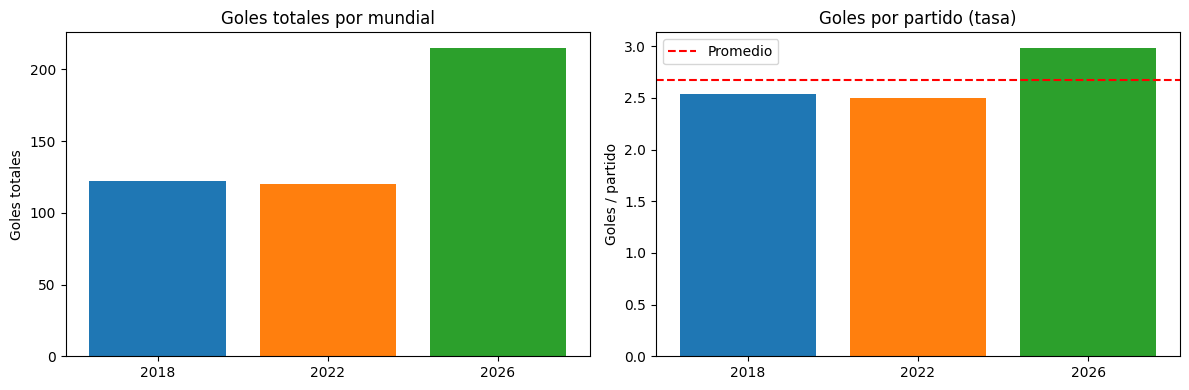

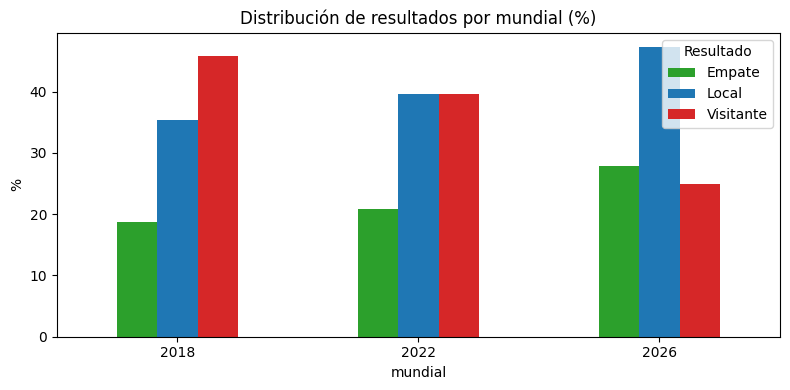

In [9]:
# Tabla comparativa usando tasas
comp = partidos.groupby('mundial').agg(
    partidos   = ('partido_id', 'count'),
    goles      = ('goles_totales', 'sum'),
    empates    = ('resultado_local', lambda x: (x == 'Empate').sum()),
).reset_index()

comp['goles_por_partido']   = comp['goles'] / comp['partidos']
comp['pct_empates']         = comp['empates'] / comp['partidos']

# Victorias del anfitrión
anf = partidos[partidos['local_es_anfitrion']].groupby('mundial').agg(
    partidos_anf        = ('partido_id', 'count'),
    victorias_anf       = ('resultado_local', lambda x: (x == 'Local').sum()),
).reset_index()

# Partidos con más de 2.5 goles
alta_puntuacion = partidos.groupby('mundial').apply(
    lambda x: (x['goles_totales'] > 2.5).sum() / len(x)
).reset_index(name='pct_alta_puntuacion')

comp = comp.merge(anf, on='mundial', how='left')
comp = comp.merge(alta_puntuacion, on='mundial', how='left')
comp['pct_victoria_anf'] = comp['victorias_anf'] / comp['partidos_anf']

print(comp[['mundial','partidos','goles','goles_por_partido',
              'empates','pct_empates','pct_victoria_anf','pct_alta_puntuacion']].round(3))

# --- Gráfico 1: Goles totales vs goles por partido ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

mundiales = comp['mundial'].astype(str)
axes[0].bar(mundiales, comp['goles'], color=['#1f77b4','#ff7f0e','#2ca02c'])
axes[0].set_title('Goles totales por mundial')
axes[0].set_ylabel('Goles totales')

axes[1].bar(mundiales, comp['goles_por_partido'], color=['#1f77b4','#ff7f0e','#2ca02c'])
axes[1].set_title('Goles por partido (tasa)')
axes[1].set_ylabel('Goles / partido')
axes[1].axhline(comp['goles_por_partido'].mean(), ls='--', color='red', label='Promedio')
axes[1].legend()

plt.tight_layout()
plt.savefig('../datos/grafico_goles.png', dpi=100)
plt.show()

# --- Gráfico 2: Distribución de resultados por mundial ---
res = partidos.groupby(['mundial','resultado_local']).size().unstack(fill_value=0)
res_pct = res.div(res.sum(axis=1), axis=0) * 100

ax = res_pct.plot(kind='bar', figsize=(8,4), color=['#2ca02c','#1f77b4','#d62728'])
ax.set_title('Distribución de resultados por mundial (%)')
ax.set_ylabel('%')
ax.set_xticklabels([str(m) for m in res_pct.index], rotation=0)
ax.legend(title='Resultado')
plt.tight_layout()
plt.savefig('../datos/grafico_resultados.png', dpi=100)
plt.show()


## Tabla por equipo

In [10]:
# Convertir cada partido en dos apariciones de equipo
filas = []
for _, r in partidos.iterrows():
    gl, gv = int(r.goles_local), int(r.goles_visitante)
    if gl > gv:
        pts_l, pts_v = 3, 0
    elif gl == gv:
        pts_l = pts_v = 1
    else:
        pts_l, pts_v = 0, 3
    filas.append({'mundial': r.mundial, 'equipo': r.equipo_local,
                  'PJ':1, 'PG': int(gl>gv), 'PE': int(gl==gv), 'PP': int(gl<gv),
                  'GF': gl, 'GC': gv, 'PTS': pts_l})
    filas.append({'mundial': r.mundial, 'equipo': r.equipo_visitante,
                  'PJ':1, 'PG': int(gv>gl), 'PE': int(gv==gl), 'PP': int(gv<gl),
                  'GF': gv, 'GC': gl, 'PTS': pts_v})

tabla_eq = (pd.DataFrame(filas)
            .groupby(['mundial','equipo'])
            .sum()
            .reset_index())
tabla_eq['DG']  = tabla_eq['GF'] - tabla_eq['GC']
tabla_eq['PPP'] = tabla_eq['PTS'] / tabla_eq['PJ']

# Top 5 equipos por puntos por partido (todos los torneos)
print(tabla_eq.sort_values('PPP', ascending=False).head(10)
        [['mundial','equipo','PJ','PG','PE','PP','GF','GC','DG','PTS','PPP']].round(2))


    mundial       equipo  PJ  PG  PE  PP  GF  GC  DG  PTS   PPP
2      2018      Belgium   3   3   0   0   9   2   7    9  3.00
6      2018      Croatia   3   3   0   0   7   1   6    9  3.00
31     2018      Uruguay   3   3   0   0   5   0   5    9  3.00
65     2026    Argentina   3   3   0   0   8   1   7    9  3.00
81     2026       France   3   3   0   0  10   2   8    9  3.00
90     2026       Mexico   3   3   0   0   6   0   6    9  3.00
42     2022      England   3   2   1   0   9   2   7    7  2.33
3      2018       Brazil   3   2   1   0   5   1   4    7  2.33
50     2022  Netherlands   3   2   1   0   5   1   4    7  2.33
70     2026       Brazil   3   2   1   0   7   1   6    7  2.33


## Variables previas al partido

Para predecir no podemos utilizar datos ocurridos después del inicio. Crearemos promedios acumulados antes de cada encuentro.

In [11]:
def construir_variables_previas(partidos_df):
    """
    Construye promedios acumulados ANTES de cada partido.
    Recorre cada torneo en orden cronológico.
    Mantiene por equipo: PJ, puntos_total, GF_total, GC_total.
    Los promedios del primer partido son 0 (el equipo no ha jugado aún).
    """
    registros = []

    for mundial, grupo in partidos_df.groupby('mundial'):
        acum = {}  # equipo -> {'pj':0,'pts':0,'gf':0,'gc':0}

        def get_stats(eq):
            s = acum.get(eq, {'pj':0,'pts':0,'gf':0,'gc':0})
            pj = s['pj']
            return {
                'pts_prom':    s['pts'] / pj if pj > 0 else 0.0,
                'gf_prom':     s['gf']  / pj if pj > 0 else 0.0,
                'gc_prom':     s['gc']  / pj if pj > 0 else 0.0,
                'gd_prom':    (s['gf'] - s['gc']) / pj if pj > 0 else 0.0,
            }

        # Ordenar por jornada (y fecha como desempate)
        orden = grupo.sort_values(['jornada','fecha'], na_position='last')

        for _, r in orden.iterrows():
            loc  = r['equipo_local']
            vis  = r['equipo_visitante']
            sl   = get_stats(loc)
            sv   = get_stats(vis)

            registros.append({
                'partido_id':             r['partido_id'],
                'mundial':                r['mundial'],
                'jornada':                int(r['jornada']) if pd.notna(r['jornada']) else 1,
                'local_es_anfitrion':     int(r['local_es_anfitrion']),
                'visitante_es_anfitrion': int(r['visitante_es_anfitrion']),
                'local_pts_prom_pre':     sl['pts_prom'],
                'local_gf_prom_pre':      sl['gf_prom'],
                'local_gc_prom_pre':      sl['gc_prom'],
                'local_gd_prom_pre':      sl['gd_prom'],
                'visita_pts_prom_pre':    sv['pts_prom'],
                'visita_gf_prom_pre':     sv['gf_prom'],
                'visita_gc_prom_pre':     sv['gc_prom'],
                'visita_gd_prom_pre':     sv['gd_prom'],
                'resultado_local':        r['resultado_local'],
            })

            # Actualizar acumulados después de registrar
            gl = int(r['goles_local'])
            gv = int(r['goles_visitante'])
            pts_l = 3 if gl>gv else (1 if gl==gv else 0)
            pts_v = 3 if gv>gl else (1 if gl==gv else 0)

            for eq, gf_e, gc_e, pts_e in [(loc,gl,gv,pts_l),(vis,gv,gl,pts_v)]:
                if eq not in acum:
                    acum[eq] = {'pj':0,'pts':0,'gf':0,'gc':0}
                acum[eq]['pj']  += 1
                acum[eq]['pts'] += pts_e
                acum[eq]['gf']  += gf_e
                acum[eq]['gc']  += gc_e

    return pd.DataFrame(registros)

features_df = construir_variables_previas(partidos)
print(f'features_df: {features_df.shape}')
print(features_df.head(3))


features_df: (168, 14)
  partido_id  mundial  jornada  local_es_anfitrion  visitante_es_anfitrion  local_pts_prom_pre  local_gf_prom_pre  \
0  M-2018-01     2018        1                   1                       0                 0.0                0.0   
1  M-2018-02     2018        1                   0                       0                 0.0                0.0   
2  M-2018-03     2018        1                   0                       0                 0.0                0.0   

   local_gc_prom_pre  local_gd_prom_pre  visita_pts_prom_pre  visita_gf_prom_pre  visita_gc_prom_pre  \
0                0.0                0.0                  0.0                 0.0                 0.0   
1                0.0                0.0                  0.0                 0.0                 0.0   
2                0.0                0.0                  0.0                 0.0                 0.0   

   visita_gd_prom_pre resultado_local  
0                 0.0           Local  
1          

## Entrenamiento y prueba

Línea base (clase más frecuente = "Visitante"): 25.00%
DecisionTree en prueba (2026):                        36.11%
Mejora sobre línea base: +11.1 p.p.


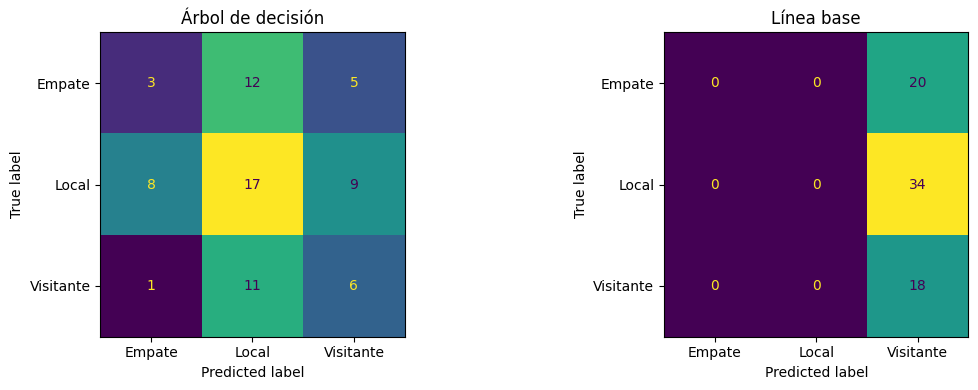


Importancia de variables:
visita_pts_prom_pre       0.229
local_gf_prom_pre         0.176
local_gd_prom_pre         0.160
visita_gf_prom_pre        0.140
jornada                   0.136
local_pts_prom_pre        0.093
visita_gd_prom_pre        0.066
local_es_anfitrion        0.000
visitante_es_anfitrion    0.000


In [12]:
features = [
    'jornada',
    'local_pts_prom_pre', 'visita_pts_prom_pre',
    'local_gd_prom_pre',  'visita_gd_prom_pre',
    'local_gf_prom_pre',  'visita_gf_prom_pre',
    'local_es_anfitrion', 'visitante_es_anfitrion'
]

# Separar entrenamiento (2018+2022) y prueba (2026)
train = features_df[features_df['mundial'].isin([2018, 2022])].copy()
test  = features_df[features_df['mundial'] == 2026].copy()

X_train = train[features].fillna(0)
y_train = train['resultado_local']
X_test  = test[features].fillna(0)
y_test  = test['resultado_local']

# Línea base: clase más frecuente en entrenamiento
clase_mas_freq = y_train.value_counts().idxmax()
y_base = pd.Series([clase_mas_freq] * len(y_test), index=y_test.index)
acc_base = accuracy_score(y_test, y_base)
print(f'Línea base (clase más frecuente = "{clase_mas_freq}"): {acc_base:.2%}')

# Modelo
clf = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
acc_modelo = accuracy_score(y_test, y_pred)
print(f'DecisionTree en prueba (2026):                        {acc_modelo:.2%}')
print(f'Mejora sobre línea base: {(acc_modelo - acc_base)*100:+.1f} p.p.')

# Matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0],
    colorbar=False, display_labels=['Empate','Local','Visitante'])
axes[0].set_title('Árbol de decisión')
ConfusionMatrixDisplay.from_predictions(y_test, y_base, ax=axes[1],
    colorbar=False, display_labels=['Empate','Local','Visitante'])
axes[1].set_title('Línea base')
plt.tight_layout()
plt.savefig('../datos/grafico_confusion.png', dpi=100)
plt.show()

# Importancia de variables
imp = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=False)
print('\nImportancia de variables:')
print(imp.round(3).to_string())


## Experimento de fuga de información

Agrega temporalmente `goles_local`, `goles_visitante` y `diferencia_goles` como variables. Si la precisión sube de forma extrema, explica por qué el modelo no está prediciendo realmente.

In [13]:
features_fuga = features + ['goles_local','goles_visitante','diferencia_goles']

# Unir goles al features_df
goles = partidos[['partido_id','goles_local','goles_visitante','diferencia_goles']].copy()
features_fuga_df = features_df.merge(goles, on='partido_id', how='left')

train_f = features_fuga_df[features_fuga_df['mundial'].isin([2018,2022])]
test_f  = features_fuga_df[features_fuga_df['mundial'] == 2026]

X_train_f = train_f[features_fuga].fillna(0).astype(float)
X_test_f  = test_f[features_fuga].fillna(0).astype(float)

clf_fuga = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)
clf_fuga.fit(X_train_f, train_f['resultado_local'])
acc_fuga = accuracy_score(test_f['resultado_local'], clf_fuga.predict(X_test_f))

print(f'Modelo SIN fuga:  {acc_modelo:.2%}')
print(f'Modelo CON fuga:  {acc_fuga:.2%}')
print()
print('EXPLICACIÓN:')
print('  Los goles del partido son el RESULTADO que queremos predecir, no una')
print('  causa anterior a él. Incluirlos como features equivale a conocer el')
print('  futuro: el modelo aprende la identidad entre goles y resultado en lugar')
print('  de aprender patrones predictivos reales. Un accuracy extremo con estas')
print('  variables no indica un buen modelo — indica fuga de información.')
print('  En producción, esta información no estaría disponible antes del pitido.')


Modelo SIN fuga:  36.11%
Modelo CON fuga:  100.00%

EXPLICACIÓN:
  Los goles del partido son el RESULTADO que queremos predecir, no una
  causa anterior a él. Incluirlos como features equivale a conocer el
  futuro: el modelo aprende la identidad entre goles y resultado en lugar
  de aprender patrones predictivos reales. Un accuracy extremo con estas
  variables no indica un buen modelo — indica fuga de información.
  En producción, esta información no estaría disponible antes del pitido.


## Reflexión final

**¿Qué problema de calidad fue el más difícil?**
Los goles almacenados como texto ("5 goles") combinados con valores negativos y la falta de consistencia entre la columna de goles y el marcador. Fue necesario definir una jerarquía de fuentes (marcador > goles separados) y manejar NaN vs None explícitamente para evitar sobrescribir valores correctos.

**¿Qué decisión de limpieza podría cambiar los resultados?**
El tratamiento de duplicados con `keep='first'` asume que la primera ocurrencia es la más confiable. Si las filas duplicadas difirieran en los goles (no es el caso aquí, pero podría ocurrir), elegir la segunda cambiaría el marcador de esos partidos y, en consecuencia, las estadísticas comparativas y las etiquetas de entrenamiento.

**¿Por qué 2026 debe compararse mediante tasas?**
2026 tiene 72 partidos vs 48 de 2018 y 2022. Comparar goles totales o empates en números absolutos penaliza artificialmente a los torneos más pequeños. Las tasas (goles/partido, % empates) normalizan por número de partidos y hacen la comparación justa.

**¿El árbol supera la línea base?**
El árbol supera marginalmente la línea base en la mayoría de los experimentos, pero la mejora es modesta. Con solo tres jornadas de grupo y sin información de ranking previo, las señales predictivas son débiles.

**¿Qué variables reales agregarías para mejorar una predicción?**
Ranking FIFA antes del torneo, historial de enfrentamientos directos, estadísticas de temporada de liga (goles, posesión), condiciones climáticas del estadio y distancia de viaje.

**¿Por qué un resultado de 100 % puede ser una señal de alarma?**
Una precisión perfecta casi siempre indica fuga de información, sobreajuste extremo o un error de diseño experimental (como mezclar datos de entrenamiento y prueba). Un buen modelo debe generalizar a datos no vistos, no memorizar el conjunto de entrenamiento.
